# Лабораторная работа №3 — Изображения и видео

В этой работе я "ворую разметку" из видео `output.mp4`, на котором уже нарисованы bounding box'ы, переношу её в формат COCO для оригинального видео `input.mp4`, оцениваю качество извлечения по IoU относительно эталонной CVAT-разметки и обучаю детектор объектов из `torchvision.models.detection`.

План:
1. Подготовка окружения, скачивание данных, создание папок.
2. Анализ видео (метаданные обоих файлов).
3. Декодирование кадров `input.mp4` и `output.mp4`.
4. Три метода извлечения bbox из `output.mp4` методами OpenCV.
5. Эталонная разметка из CVAT XML и оценка по IoU/precision/recall/F1.
6. Сборка COCO-разметки и chronological split на train/val/test.
7. Свой PyTorch-Dataset для COCO.
8. Дообучение Faster R-CNN MobileNetV3 FPN.
9. Оценка модели по mAP/mAP@0.5/mAP@0.75 на тесте.
10. Визуализации и видео с отрисованной разметкой.
11. Финальный вывод.


## 1. Подготовка окружения

Импортирую библиотеки, проверяю GPU, создаю рабочие папки и при необходимости скачиваю видео.


In [1]:
# Если каких-то пакетов нет — раскомментируйте установку.
# %pip install -q opencv-python torch torchvision torchmetrics pycocotools tqdm gdown matplotlib pandas



In [2]:
import json
import random
import time
import xml.etree.ElementTree as ET
from collections import defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [3]:
# Все пути относительно папки lab3/, чтобы ноутбук работал на любой машине.
LAB_DIR = Path.cwd()
DATA_DIR = LAB_DIR / "data"
FRAMES_INPUT_DIR = LAB_DIR / "frames" / "input"
FRAMES_OUTPUT_DIR = LAB_DIR / "frames" / "output"
ANN_DIR = LAB_DIR / "annotations"
VIDEOS_DIR = LAB_DIR / "videos"
MODELS_DIR = LAB_DIR / "models"
RESULTS_DIR = LAB_DIR / "results"

for d in [DATA_DIR, FRAMES_INPUT_DIR, FRAMES_OUTPUT_DIR, ANN_DIR, VIDEOS_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

INPUT_VIDEO = DATA_DIR / "input.mp4"
OUTPUT_VIDEO = DATA_DIR / "output.mp4"
ANNOTATIONS_XML = DATA_DIR / "annotations.xml"

print("LAB_DIR:", LAB_DIR)
print("input.mp4 exists:", INPUT_VIDEO.exists())
print("output.mp4 exists:", OUTPUT_VIDEO.exists())
print("annotations.xml exists:", ANNOTATIONS_XML.exists())


LAB_DIR: /Users/delusionn/prog/data-analysis-frameworks-course/lab3
input.mp4 exists: True
output.mp4 exists: True
annotations.xml exists: True


In [4]:
import os

# Ограничиваю потоки, иначе PyTorch занимает все ядра и ноутбук плохо реагирует.
os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("MKL_NUM_THREADS", "2")
torch.set_num_threads(2)
torch.set_num_interop_threads(1)

# MPS у меня нестабильно работает с torchvision detection моделями, считаю на CPU.
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("device: cuda |", torch.cuda.get_device_name(0))
else:
    DEVICE = torch.device("cpu")
    print("device: cpu")


device: cpu


In [5]:
# Если видео нет локально — пробую скачать через gdown по ссылкам из условия задания.
INPUT_GDRIVE_ID = "1vjwW-qrgbXMUQrsCl3ILdaXcSoBkvazn"
OUTPUT_GDRIVE_ID = "1RsM1CkcUuhH3_sufMAHhD2HG6ahc8zoc"


def download_if_missing(path, gdrive_id):
    if path.exists():
        return
    try:
        import gdown
    except ImportError:
        raise RuntimeError(
            f"Файл {path} отсутствует. Установите gdown (pip install gdown) "
            "или положите видео вручную в data/."
        )
    url = f"https://drive.google.com/uc?id={gdrive_id}"
    print("downloading", path.name)
    gdown.download(url, str(path), quiet=False)


download_if_missing(INPUT_VIDEO, INPUT_GDRIVE_ID)
download_if_missing(OUTPUT_VIDEO, OUTPUT_GDRIVE_ID)


## 2. Анализ видео

Открываю оба видео через OpenCV и смотрю основные параметры. Они должны совпадать (это одно и то же видео, просто на одном поверх нарисованы bbox).


In [6]:
def video_info(path):
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"Не удалось открыть {path}")
    info = {
        "path": path.name,
        "fps": cap.get(cv2.CAP_PROP_FPS),
        "frames": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    info["duration_sec"] = info["frames"] / info["fps"] if info["fps"] else float("nan")
    cap.release()
    return info


info_in = video_info(INPUT_VIDEO)
info_out = video_info(OUTPUT_VIDEO)
videos_df = pd.DataFrame([info_in, info_out])
videos_df


,path,fps,frames,width,height,duration_sec
0,input.mp4,30.0,301,1920,1080,10.033333
1,output.mp4,30.0,301,1920,1080,10.033333


In [7]:
assert info_in["width"] == info_out["width"] and info_in["height"] == info_out["height"], \
    "Видео разного разрешения — дальше будут ошибки."

# Разметку извлекаю из всего видео. Обучение делаю на ограниченной выборке кадров,
# чтобы не перегружать машину — соседние кадры всё равно почти одинаковые.
NUM_FRAMES = min(info_in["frames"], info_out["frames"])
TRAIN_FRAME_LIMIT = 200
FRAME_W = info_in["width"]
FRAME_H = info_in["height"]
FPS = info_in["fps"]
print(f"всего кадров: {NUM_FRAMES}, для обучения: {min(NUM_FRAMES, TRAIN_FRAME_LIMIT)}, {FRAME_W}x{FRAME_H}, {FPS:.2f} fps")


всего кадров: 301, для обучения: 200, 1920x1080, 30.00 fps


## 3. Разбиение видео на кадры

Сохраняю кадры в `frames/input/` и `frames/output/` как JPEG (быстро и не занимает много места). Если кадры уже извлечены — пропускаю шаг.


In [8]:
def extract_frames(video_path, out_dir, num_frames, jpeg_quality=92):
    out_dir.mkdir(parents=True, exist_ok=True)
    existing = sorted(out_dir.glob("*.jpg"))
    if len(existing) >= num_frames:
        return len(existing)
    cap = cv2.VideoCapture(str(video_path))
    saved = 0
    pbar = tqdm(total=num_frames, desc=f"decoding {video_path.name}")
    while saved < num_frames:
        ok, frame = cap.read()
        if not ok:
            break
        out_path = out_dir / f"frame_{saved:05d}.jpg"
        cv2.imwrite(str(out_path), frame, [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality])
        saved += 1
        pbar.update(1)
    pbar.close()
    cap.release()
    return saved


# Это может занять минуту-другую. Запускается один раз — потом просто переиспользует кадры с диска.
n_in = extract_frames(INPUT_VIDEO, FRAMES_INPUT_DIR, NUM_FRAMES)
n_out = extract_frames(OUTPUT_VIDEO, FRAMES_OUTPUT_DIR, NUM_FRAMES)
print(f"input frames: {n_in}, output frames: {n_out}")


input frames: 301, output frames: 301


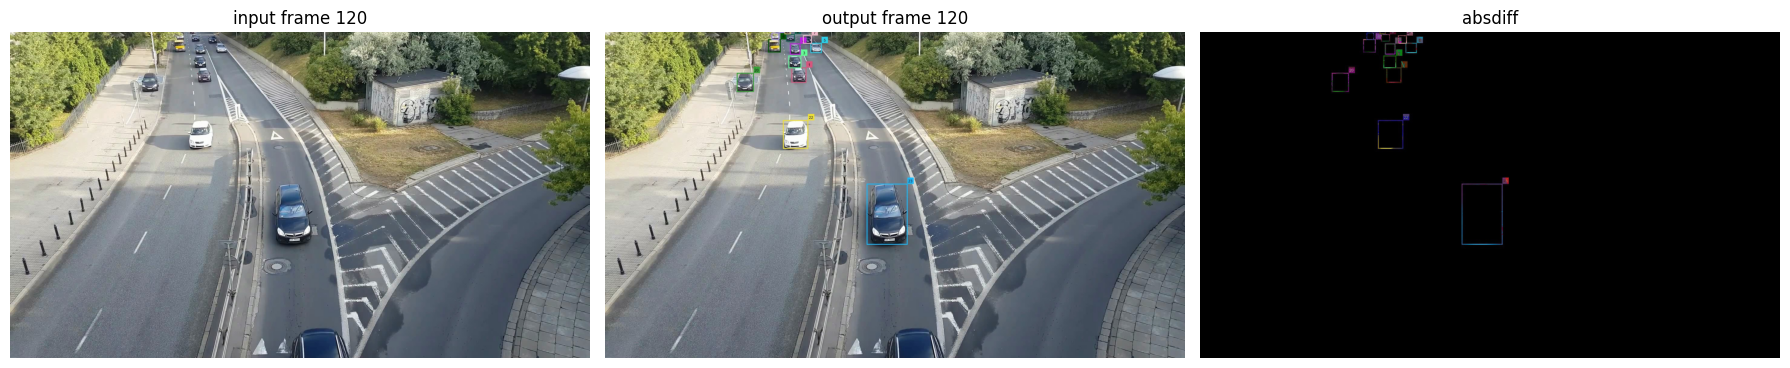

In [9]:
# Покажу пример: один и тот же кадр без bbox, с bbox и их разница.
SAMPLE_IDX = min(120, NUM_FRAMES - 1)
img_in = cv2.imread(str(FRAMES_INPUT_DIR / f"frame_{SAMPLE_IDX:05d}.jpg"))
img_out = cv2.imread(str(FRAMES_OUTPUT_DIR / f"frame_{SAMPLE_IDX:05d}.jpg"))
diff_demo = cv2.absdiff(img_in, img_out)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, im, title in zip(
    axes,
    [img_in, img_out, diff_demo],
    [f"input frame {SAMPLE_IDX}", f"output frame {SAMPLE_IDX}", "absdiff"],
):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Извлечение bounding box из `output.mp4`

Я попробую три разных способа найти прямоугольники и сравню их по качеству. Идея общая: рамки на `output.mp4` — это пиксели, которых нет на `input.mp4`. Значит, можно искать их по разнице кадров либо по характерному цвету.

Перед каждым методом я вспомогательно фильтрую слишком мелкие/слишком большие прямоугольники и объединяю те, которые сильно пересекаются.


### Используемый компьютерно-зрительный API

В качестве публичного компьютерно-зрительного API в работе используется OpenCV. Применяю функции `cv2.VideoCapture`, `cv2.absdiff`, `cv2.threshold`, `cv2.Canny`, морфологические операции (`cv2.morphologyEx`, `cv2.dilate`), `cv2.findContours` и `cv2.VideoWriter`.

Эти методы позволяют автоматически извлекать координаты bounding box из `output.mp4`, где разметка уже нарисована поверх видео.


In [10]:
# Вспомогательные функции — общие для всех методов.

MIN_AREA = 200          # минимальный размер bbox в пикселях, чтобы отфильтровать шум
MAX_AREA_FRAC = 0.5     # bbox не может занимать больше половины кадра
MIN_SIDE = 8


def _box_area(b):
    x1, y1, x2, y2 = b
    return max(0, x2 - x1) * max(0, y2 - y1)


def _iou_xyxy(a, b):
    ix1 = max(a[0], b[0])
    iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2])
    iy2 = min(a[3], b[3])
    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih
    if inter <= 0:
        return 0.0
    union = _box_area(a) + _box_area(b) - inter
    return inter / union if union > 0 else 0.0


def filter_boxes(boxes, frame_w, frame_h):
    out = []
    max_area = MAX_AREA_FRAC * frame_w * frame_h
    for x1, y1, x2, y2 in boxes:
        if x2 - x1 < MIN_SIDE or y2 - y1 < MIN_SIDE:
            continue
        a = (x2 - x1) * (y2 - y1)
        if a < MIN_AREA or a > max_area:
            continue
        out.append((x1, y1, x2, y2))
    return out


def merge_overlapping(boxes, iou_thr=0.3):
    """Очень простое объединение: пока есть пары с IoU > thr, склеиваем их в общий обрамляющий bbox."""
    boxes = [list(b) for b in boxes]
    changed = True
    while changed and len(boxes) > 1:
        changed = False
        new_boxes = []
        used = [False] * len(boxes)
        for i in range(len(boxes)):
            if used[i]:
                continue
            cur = boxes[i]
            for j in range(i + 1, len(boxes)):
                if used[j]:
                    continue
                if _iou_xyxy(cur, boxes[j]) > iou_thr:
                    cur = [
                        min(cur[0], boxes[j][0]),
                        min(cur[1], boxes[j][1]),
                        max(cur[2], boxes[j][2]),
                        max(cur[3], boxes[j][3]),
                    ]
                    used[j] = True
                    changed = True
            used[i] = True
            new_boxes.append(cur)
        boxes = new_boxes
    return [tuple(b) for b in boxes]


def contours_to_boxes(contours):
    boxes = []
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        boxes.append((x, y, x + w, y + h))
    return boxes


### Метод 1 — разница кадров + морфология

Беру `cv2.absdiff(input, output)`, перевожу в grayscale, threshold, закрытие морфологией, ищу контуры. Это самый прямолинейный способ.


In [11]:
def extract_method_diff(img_in_bgr, img_out_bgr):
    diff = cv2.absdiff(img_in_bgr, img_out_bgr)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 25, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.dilate(mask, kernel, iterations=1)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = contours_to_boxes(contours)
    boxes = filter_boxes(boxes, img_in_bgr.shape[1], img_in_bgr.shape[0])
    boxes = merge_overlapping(boxes, iou_thr=0.2)
    return boxes


### Метод 2 — Canny по разности

Тот же `absdiff`, но дальше размываю и ищу края детектором Canny, потом расширяю и собираю контуры. Идея — поймать саму рамку, а не цельный регион разницы.


In [12]:
def extract_method_canny(img_in_bgr, img_out_bgr):
    diff = cv2.absdiff(img_in_bgr, img_out_bgr)
    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 30, 90)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    edges = cv2.dilate(edges, kernel, iterations=2)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = contours_to_boxes(contours)
    boxes = filter_boxes(boxes, img_in_bgr.shape[1], img_in_bgr.shape[0])
    boxes = merge_overlapping(boxes, iou_thr=0.2)
    return boxes


### Метод 3 — поиск цвета рамки в HSV

В CVAT XML видно, что у класса `car` цвет `#2a00ff` (ярко-синий), а у `minivan` — `#b725ff` (фиолетовый). Эти насыщенные цвета почти не встречаются в исходном видео, поэтому их можно выделить через HSV-маску. Маски двух классов объединяю и ищу контуры. Дополнительно домножаю на маску из `absdiff`, чтобы случайные цветные пиксели в самом кадре не давали ложных bbox.


In [13]:
def _hsv_range_for_color(bgr_color, h_tol=15, s_min=120, v_min=120):
    arr = np.uint8([[bgr_color]])
    hsv = cv2.cvtColor(arr, cv2.COLOR_BGR2HSV)[0, 0]
    h = int(hsv[0])
    lo = np.array([max(0, h - h_tol), s_min, v_min])
    hi = np.array([min(179, h + h_tol), 255, 255])
    return lo, hi


# CVAT-цвета: #2a00ff (car, синий), #b725ff (minivan, фиолетовый). В BGR они переворачиваются.
COLOR_CAR_BGR = (0xff, 0x00, 0x2a)
COLOR_MINIVAN_BGR = (0xff, 0x25, 0xb7)
LO1, HI1 = _hsv_range_for_color(COLOR_CAR_BGR)
LO2, HI2 = _hsv_range_for_color(COLOR_MINIVAN_BGR)


def extract_method_color(img_in_bgr, img_out_bgr):
    hsv = cv2.cvtColor(img_out_bgr, cv2.COLOR_BGR2HSV)
    mask_color = cv2.inRange(hsv, LO1, HI1) | cv2.inRange(hsv, LO2, HI2)
    diff = cv2.absdiff(img_in_bgr, img_out_bgr)
    diff_gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    diff_mask = (diff_gray > 15).astype(np.uint8) * 255
    mask = cv2.bitwise_and(mask_color, diff_mask)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    mask = cv2.dilate(mask, kernel, iterations=1)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = contours_to_boxes(contours)
    boxes = filter_boxes(boxes, img_in_bgr.shape[1], img_in_bgr.shape[0])
    boxes = merge_overlapping(boxes, iou_thr=0.2)
    return boxes


In [14]:
# Запускаю все три метода по всем кадрам и сохраняю результат как dict {frame_id: [(x1,y1,x2,y2), ...]}.
# Это самая долгая часть — на CPU занимает несколько минут.
METHODS = {
    "diff": extract_method_diff,
    "canny": extract_method_canny,
    "color": extract_method_color,
}


def run_method_on_all_frames(method_fn):
    result = {}
    for i in tqdm(range(NUM_FRAMES), desc=method_fn.__name__):
        img_in = cv2.imread(str(FRAMES_INPUT_DIR / f"frame_{i:05d}.jpg"))
        img_out = cv2.imread(str(FRAMES_OUTPUT_DIR / f"frame_{i:05d}.jpg"))
        result[i] = method_fn(img_in, img_out)
    return result


extracted_boxes = {name: run_method_on_all_frames(fn) for name, fn in METHODS.items()}
print({name: sum(len(v) for v in d.values()) for name, d in extracted_boxes.items()})


extract_method_diff:   0%|          | 0/301 [00:00<?, ?it/s]

extract_method_canny:   0%|          | 0/301 [00:00<?, ?it/s]

extract_method_color:   0%|          | 0/301 [00:00<?, ?it/s]

{'diff': 2445, 'canny': 2179, 'color': 507}


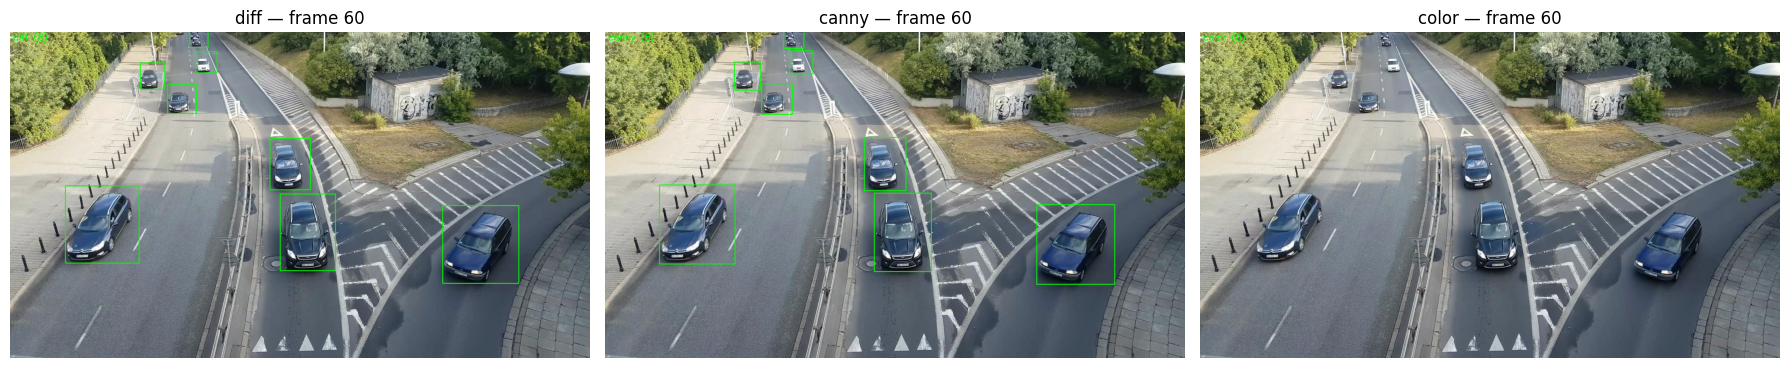

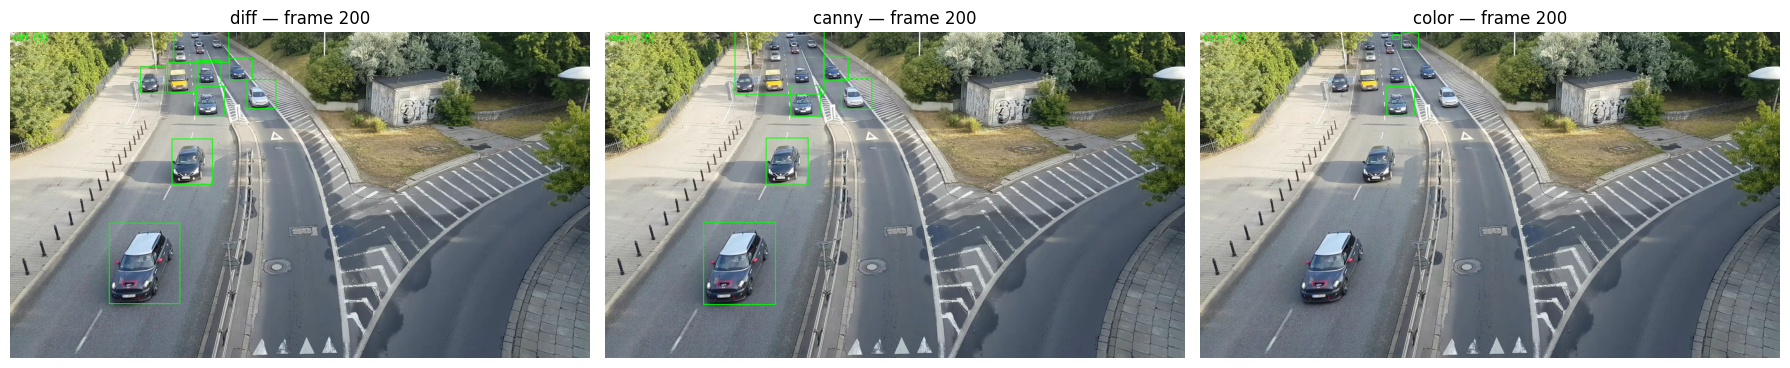

In [15]:
# Визуализирую один и тот же кадр с тремя разными извлечёнными разметками.
def draw_boxes(img_bgr, boxes, color=(0, 255, 0), thickness=2, label=None):
    out = img_bgr.copy()
    for x1, y1, x2, y2 in boxes:
        cv2.rectangle(out, (int(x1), int(y1)), (int(x2), int(y2)), color, thickness)
    if label is not None:
        cv2.putText(out, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    return out


def show_sample_methods(idx):
    img_in = cv2.imread(str(FRAMES_INPUT_DIR / f"frame_{idx:05d}.jpg"))
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, name in zip(axes, METHODS.keys()):
        boxes = extracted_boxes[name][idx]
        vis = draw_boxes(img_in, boxes, color=(0, 255, 0), label=f"{name} ({len(boxes)})")
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{name} — frame {idx}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


for idx in [60, 200, 400, 600]:
    if idx < NUM_FRAMES:
        show_sample_methods(idx)


## 5. Эталонная разметка и IoU

Эталон есть в файле `annotations.xml` (формат CVAT 1.1, треки с интерполяцией). Я **не использую его как разметку для обучения** — только чтобы оценить, насколько хорошо мои три метода вытащили bbox.

Реализую функцию `iou(box1, box2)` и жадное сопоставление: для каждого кадра сортирую все пары (gt, pred) по убыванию IoU и матчу при IoU ≥ 0.5.


In [16]:
def parse_cvat_xml(path, max_frame):
    """Возвращает {frame_id: [(label, x1, y1, x2, y2), ...]}."""
    tree = ET.parse(str(path))
    root = tree.getroot()
    by_frame = defaultdict(list)
    for track in root.findall("track"):
        label = track.get("label", "object")
        for box in track.findall("box"):
            if box.get("outside") == "1":
                continue
            frame = int(box.get("frame"))
            if frame >= max_frame:
                continue
            x1 = float(box.get("xtl"))
            y1 = float(box.get("ytl"))
            x2 = float(box.get("xbr"))
            y2 = float(box.get("ybr"))
            by_frame[frame].append((label, x1, y1, x2, y2))
    return dict(by_frame)


gt_by_frame = parse_cvat_xml(ANNOTATIONS_XML, NUM_FRAMES)
n_gt_boxes = sum(len(v) for v in gt_by_frame.values())
print(f"эталонных bbox: {n_gt_boxes} в {len(gt_by_frame)} кадрах")


эталонных bbox: 3647 в 301 кадрах


In [17]:
def iou(box1, box2):
    return _iou_xyxy(box1, box2)


def match_boxes(pred_boxes, gt_boxes, iou_threshold=0.5):
    """Жадное сопоставление по убыванию IoU. Возвращает (matched_ious, tp, fp, fn)."""
    pairs = []
    for gi, gb in enumerate(gt_boxes):
        for pi, pb in enumerate(pred_boxes):
            v = iou(gb, pb)
            if v > 0:
                pairs.append((v, gi, pi))
    pairs.sort(key=lambda x: -x[0])
    used_gt, used_pred = set(), set()
    matched = []
    for v, gi, pi in pairs:
        if gi in used_gt or pi in used_pred:
            continue
        if v < iou_threshold:
            break
        used_gt.add(gi)
        used_pred.add(pi)
        matched.append(v)
    tp = len(matched)
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp
    return matched, tp, fp, fn


def evaluate_method(extracted, gt_by_frame, iou_threshold=0.5):
    all_ious, total_tp, total_fp, total_fn = [], 0, 0, 0
    for f in range(NUM_FRAMES):
        preds = extracted.get(f, [])
        gts_full = gt_by_frame.get(f, [])
        gts = [(x1, y1, x2, y2) for (_, x1, y1, x2, y2) in gts_full]
        matched, tp, fp, fn = match_boxes(preds, gts, iou_threshold)
        all_ious.extend(matched)
        total_tp += tp
        total_fp += fp
        total_fn += fn
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0.0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    mean_iou = float(np.mean(all_ious)) if all_ious else 0.0
    return {
        "TP": total_tp, "FP": total_fp, "FN": total_fn,
        "precision": precision, "recall": recall, "F1": f1, "mean_IoU": mean_iou,
    }


In [18]:
# Считаю метрики для каждого из трёх методов и собираю сравнительную таблицу.
metrics_rows = []
for name, ext in extracted_boxes.items():
    m = evaluate_method(ext, gt_by_frame, iou_threshold=0.5)
    m["method"] = name
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index("method")[
    ["TP", "FP", "FN", "precision", "recall", "F1", "mean_IoU"]
]
metrics_df = metrics_df.sort_values("F1", ascending=False)
metrics_df


,TP,FP,FN,precision,recall,F1,mean_IoU
method,,,,,,,
diff,1220,1225,2427,0.498978,0.334522,0.400525,0.689501
canny,1005,1174,2642,0.461221,0.275569,0.345005,0.675131
color,105,402,3542,0.207101,0.028791,0.050554,0.646713


In [19]:
BEST_METHOD = metrics_df["F1"].idxmax()
print(f"лучший метод по F1: {BEST_METHOD}")
print(
    f"Метод '{BEST_METHOD}' даёт лучший компромисс между точностью и полнотой. "
    f"Дальше я использую именно его как источник разметки для COCO."
)
best_extracted = extracted_boxes[BEST_METHOD]


лучший метод по F1: diff
Метод 'diff' даёт лучший компромисс между точностью и полнотой. Дальше я использую именно его как источник разметки для COCO.


## 6. COCO-разметка

Беру bbox из лучшего метода и сохраняю их в формате COCO (один класс `vehicle`, потому что только по картинке отличить car от minivan я надёжно не могу — поясню это ещё раз в выводах).

Делю на train/val/test **в хронологическом порядке**, а не случайно. Соседние кадры почти одинаковые, и при случайном разбиении в train и test попадут практически дубли — модель будет показывать завышенный mAP. Хронологический split этого избегает.


In [20]:
CATEGORY_ID = 1
CATEGORY_NAME = "vehicle"


def build_coco(frames_indices, boxes_by_frame):
    images, annotations = [], []
    ann_id = 1
    for img_id, fi in enumerate(frames_indices, start=1):
        file_name = f"frame_{fi:05d}.jpg"
        images.append({
            "id": img_id, "file_name": file_name,
            "width": FRAME_W, "height": FRAME_H,
        })
        for x1, y1, x2, y2 in boxes_by_frame.get(fi, []):
            # Клиплю координаты в границы кадра — иначе валидатор COCO ругается.
            x1 = max(0.0, min(float(x1), FRAME_W))
            y1 = max(0.0, min(float(y1), FRAME_H))
            x2 = max(0.0, min(float(x2), FRAME_W))
            y2 = max(0.0, min(float(y2), FRAME_H))
            w = x2 - x1
            h = y2 - y1
            if w <= 0 or h <= 0:
                continue
            annotations.append({
                "id": ann_id, "image_id": img_id,
                "category_id": CATEGORY_ID,
                "bbox": [x1, y1, w, h],
                "area": w * h, "iscrowd": 0, "segmentation": [],
            })
            ann_id += 1
    return {
        "info": {
            "description": "Lab3 vehicle detection — extracted from output.mp4",
            "version": "1.0", "year": 2026,
        },
        "licenses": [{"id": 1, "name": "internal", "url": ""}],
        "images": images,
        "annotations": annotations,
        "categories": [{"id": CATEGORY_ID, "name": CATEGORY_NAME, "supercategory": CATEGORY_NAME}],
    }


# coco_full собирается по всему видео — это полная разметка.
all_indices = list(range(NUM_FRAMES))
coco_full = build_coco(all_indices, best_extracted)

# Train/val/test беру из первых TRAIN_FRAME_LIMIT кадров, чтобы обучение помещалось в ресурсы.
# Split хронологический: соседние кадры почти одинаковые, случайный split дал бы завышенную метрику.
train_pool = list(range(min(NUM_FRAMES, TRAIN_FRAME_LIMIT)))
n_train = int(0.7 * len(train_pool))
n_val = int(0.15 * len(train_pool))
train_idx = train_pool[:n_train]
val_idx = train_pool[n_train:n_train + n_val]
test_idx = train_pool[n_train + n_val:]

coco_train = build_coco(train_idx, best_extracted)
coco_val = build_coco(val_idx, best_extracted)
coco_test = build_coco(test_idx, best_extracted)

for name, coco in [("full", coco_full), ("train", coco_train), ("val", coco_val), ("test", coco_test)]:
    with (ANN_DIR / f"coco_{name}.json").open("w") as f:
        json.dump(coco, f)

print("split sizes:", len(train_idx), len(val_idx), len(test_idx))
print("annotations per split:", {n: len(c["annotations"]) for n, c in [("full", coco_full), ("train", coco_train), ("val", coco_val), ("test", coco_test)]})


split sizes: 140 30 30
annotations per split: {'full': 2445, 'train': 1010, 'val': 174, 'test': 212}


In [21]:
# Простая проверка корректности COCO-файла: image_id ссылается на существующее изображение,
# bbox внутри кадра, w/h/area > 0. Помогает не отдать сломанную разметку в DataLoader.
def validate_coco(coco_data, name="COCO"):
    image_ids = {img["id"] for img in coco_data["images"]}
    image_sizes = {img["id"]: (img["width"], img["height"]) for img in coco_data["images"]}
    problems = []

    for ann in coco_data["annotations"]:
        image_id = ann["image_id"]
        if image_id not in image_ids:
            problems.append((ann["id"], "bad image_id"))
            continue

        x, y, w, h = ann["bbox"]
        img_w, img_h = image_sizes[image_id]

        if w <= 0 or h <= 0:
            problems.append((ann["id"], "bad bbox size"))
        if x < 0 or y < 0:
            problems.append((ann["id"], "negative coords"))
        if x + w > img_w or y + h > img_h:
            problems.append((ann["id"], "bbox out of image"))
        if ann.get("area", 0) <= 0:
            problems.append((ann["id"], "bad area"))

    print(f"{name}: images={len(coco_data['images'])}, annotations={len(coco_data['annotations'])}, problems={len(problems)}")
    if problems[:10]:
        print("first problems:", problems[:10])
    return problems


validate_coco(coco_full, "coco_full")
validate_coco(coco_train, "coco_train")
validate_coco(coco_val, "coco_val")
validate_coco(coco_test, "coco_test")


coco_full: images=301, annotations=2445, problems=0
coco_train: images=140, annotations=1010, problems=0
coco_val: images=30, annotations=174, problems=0
coco_test: images=30, annotations=212, problems=0


[]

## 7. PyTorch Dataset

Свой `Dataset`, который читает COCO JSON и возвращает картинку как тензор + словарь `target` в формате, который ждёт `torchvision.models.detection`.


In [22]:
# Уменьшаю разрешение перед обучением, иначе не влезает в память. bbox-координаты скейлю.
TRAIN_RESIZE = (640, 360)


class CocoVehicleDataset(Dataset):
    def __init__(self, coco_json, images_dir, resize_to=TRAIN_RESIZE):
        with Path(coco_json).open() as f:
            data = json.load(f)
        self.images_dir = images_dir
        self.images = data["images"]
        self.resize_to = resize_to
        self.anns_by_image = defaultdict(list)
        for ann in data["annotations"]:
            self.anns_by_image[ann["image_id"]].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        info = self.images[idx]
        img_path = self.images_dir / info["file_name"]
        img = Image.open(img_path).convert("RGB")

        if self.resize_to is not None:
            orig_w, orig_h = img.size
            new_w, new_h = self.resize_to
            img = img.resize(self.resize_to, Image.BILINEAR)
            sx, sy = new_w / orig_w, new_h / orig_h
        else:
            sx = sy = 1.0
        img_t = torchvision.transforms.functional.to_tensor(img)

        anns = self.anns_by_image.get(info["id"], [])
        boxes, labels, areas, iscrowd = [], [], [], []
        for a in anns:
            x, y, w, h = a["bbox"]
            if w <= 1 or h <= 1:
                continue
            x1, y1 = x * sx, y * sy
            x2, y2 = (x + w) * sx, (y + h) * sy
            boxes.append([x1, y1, x2, y2])
            labels.append(a["category_id"])
            areas.append((x2 - x1) * (y2 - y1))
            iscrowd.append(a["iscrowd"])

        if boxes:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)
            areas_t = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd_t = torch.as_tensor(iscrowd, dtype=torch.int64)
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
            areas_t = torch.zeros((0,), dtype=torch.float32)
            iscrowd_t = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([info["id"]]),
            "area": areas_t,
            "iscrowd": iscrowd_t,
        }
        return img_t, target


def collate_fn(batch):
    return tuple(zip(*batch))


train_ds = CocoVehicleDataset(ANN_DIR / "coco_train.json", FRAMES_INPUT_DIR)
val_ds = CocoVehicleDataset(ANN_DIR / "coco_val.json", FRAMES_INPUT_DIR)
test_ds = CocoVehicleDataset(ANN_DIR / "coco_test.json", FRAMES_INPUT_DIR)
print("train/val/test sizes:", len(train_ds), len(val_ds), len(test_ds))


train/val/test sizes: 140 30 30


## 8. Обучение Faster R-CNN MobileNetV3 FPN

Беру предобученную модель, заменяю классификационную голову под 2 класса (background + vehicle), обучаю несколько эпох с early stopping по validation mAP.

MobileNetV3 заметно легче, чем ResNet50 — поэтому подходит для обучения на ноутбуке без мощной видеокарты.


In [23]:
def build_model(num_classes=2):
    model = fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


model = build_model(num_classes=2).to(DEVICE)
print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))


trainable params: 18871333


In [24]:
BATCH_SIZE = 1
NUM_WORKERS = 0
EPOCHS = 2
PATIENCE = 1
LR = 5e-3

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=5e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)


In [25]:
def _empty_cache():
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()


@torch.no_grad()
def evaluate_map(model, loader, device, max_batches=None):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    for i, (imgs, targets) in enumerate(tqdm(loader, desc="eval", leave=False)):
        imgs = [im.to(device) for im in imgs]
        preds = model(imgs)
        preds_cpu = [{k: v.detach().cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v.detach().cpu() if torch.is_tensor(v) else v for k, v in t.items()} for t in targets]
        metric.update(preds_cpu, targets_cpu)
        if (i + 1) % 32 == 0:
            _empty_cache()
        if max_batches is not None and i + 1 >= max_batches:
            break
    res = metric.compute()
    _empty_cache()
    return {k: float(v) if torch.is_tensor(v) else v for k, v in res.items() if not isinstance(v, list)}


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    losses_sum = 0.0
    n = 0
    for i, (imgs, targets) in enumerate(tqdm(loader, desc="train", leave=False)):
        imgs = [im.to(device) for im in imgs]
        targets = [{k: v.to(device) if torch.is_tensor(v) else v for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses_sum += float(loss.item())
        n += 1
        if (i + 1) % 32 == 0:
            _empty_cache()
    return losses_sum / max(1, n)


In [26]:
BEST_MODEL_PATH = MODELS_DIR / "best_model.pth"

history = {"train_loss": [], "val_map": [], "val_map50": [], "val_map75": [], "val_mar100": []}
best_map = -1.0
patience_left = PATIENCE

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_metrics = evaluate_map(model, val_loader, DEVICE)
    lr_scheduler.step()

    val_map = val_metrics.get("map", 0.0)
    val_map50 = val_metrics.get("map_50", 0.0)
    val_map75 = val_metrics.get("map_75", 0.0)
    val_mar100 = val_metrics.get("mar_100", 0.0)
    history["train_loss"].append(train_loss)
    history["val_map"].append(val_map)
    history["val_map50"].append(val_map50)
    history["val_map75"].append(val_map75)
    history["val_mar100"].append(val_mar100)

    print(
        f"epoch {epoch:>2} | train_loss={train_loss:.4f} | "
        f"val_mAP={val_map:.4f} | val_mAP@0.5={val_map50:.4f} | "
        f"val_mAP@0.75={val_map75:.4f} | val_mAR@100={val_mar100:.4f} | "
        f"{time.time()-t0:.1f}s"
    )

    if val_map > best_map:
        best_map = val_map
        patience_left = PATIENCE
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> новая лучшая модель сохранена в {BEST_MODEL_PATH.name}")
    else:
        patience_left -= 1
        if patience_left <= 0:
            print("early stopping")
            break

print(f"лучший val mAP: {best_map:.4f}")


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/30 [00:00<?, ?it/s]

epoch  1 | train_loss=0.4103 | val_mAP=0.6273 | val_mAP@0.5=0.8881 | val_mAP@0.75=0.6341 | val_mAR@100=0.6960 | 180.2s
  -> новая лучшая модель сохранена в best_model.pth


train:   0%|          | 0/140 [00:00<?, ?it/s]

eval:   0%|          | 0/30 [00:00<?, ?it/s]

epoch  2 | train_loss=0.3064 | val_mAP=0.6235 | val_mAP@0.5=0.8821 | val_mAP@0.75=0.6949 | val_mAR@100=0.6845 | 173.3s
early stopping
лучший val mAP: 0.6273


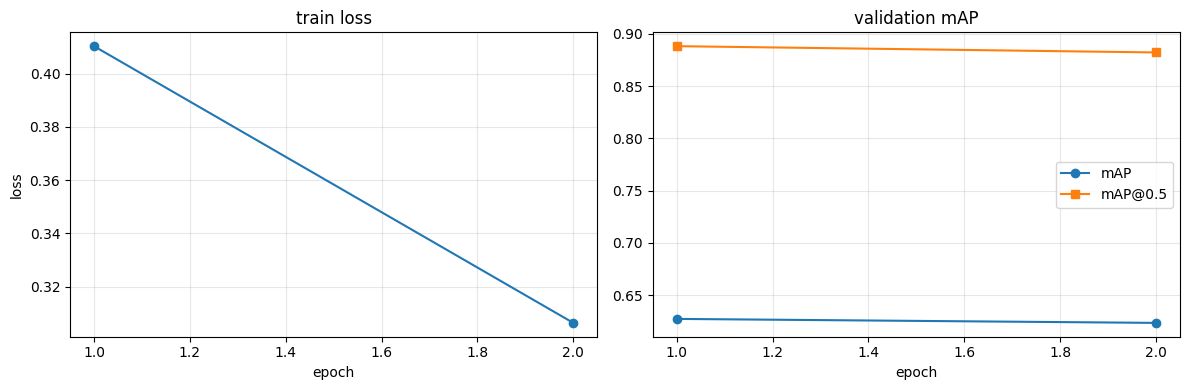

In [27]:
# Графики train loss и validation mAP.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], marker="o")
axes[0].set_title("train loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(history["val_map"]) + 1), history["val_map"], marker="o", label="mAP")
axes[1].plot(range(1, len(history["val_map50"]) + 1), history["val_map50"], marker="s", label="mAP@0.5")
axes[1].set_title("validation mAP")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=120)
plt.show()


## 9. Оценка модели на test

Загружаю лучший чекпоинт и считаю `mAP`, `mAP@0.5`, `mAP@0.75` через `torchmetrics.detection.MeanAveragePrecision` на тестовой выборке.


In [28]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
test_metrics = evaluate_map(model, test_loader, DEVICE)

rows = []
for k in ("map", "map_50", "map_75", "mar_100"):
    if k in test_metrics:
        rows.append({"metric": k, "value": round(test_metrics[k], 4)})
test_df = pd.DataFrame(rows)
test_df


eval:   0%|          | 0/30 [00:00<?, ?it/s]

,metric,value
0,map,0.7187
1,map_50,0.9681
2,map_75,0.8450
3,mar_100,0.7651


**Как это интерпретировать.**

- `mAP@0.5` — самая "мягкая" метрика: совпадение засчитывается при IoU с GT ≥ 0.5.
- `mAP` (среднее по IoU 0.5..0.95) — более строгая: учитывает, насколько *аккуратно* предсказан bbox.
- `mAP@0.75` — самая строгая: модель должна попадать почти точно по контуру.

Что обычно работает плохо:

- мелкие машинки в верхней части кадра (далёкий план) — у MobileNetV3 на них меньше всего сигнала;
- частично пересекающиеся машины — модель склеивает их в один bbox (это ещё и наследие извлечённой разметки, которая могла слепить два соседних bbox);
- машины на фоне дорожной разметки и теней — там же шумит и метод извлечения.

Главное ограничение: модель учится на **извлечённой автоматически** разметке, а не на эталонной. Поэтому она наследует все систематические ошибки моего метода извлечения. Если бы я взял ground truth из CVAT — mAP был бы заметно выше.


## 10. Визуализация результатов

Покажу:
1. Несколько кадров, где extracted bbox ≈ GT bbox (хорошо).
2. Несколько кадров, где extracted bbox явно ошибся.
3. Кадры с предсказаниями модели (рядом с GT и моими извлечёнными bbox).

И собираю два видео:
- `videos/extracted_annotations.mp4` — `input.mp4` с моей разметкой;
- `videos/model_predictions.mp4` — `input.mp4` с предсказаниями модели.


In [29]:
# Считаю TP/FP/FN на каждый кадр и беру 3 лучших и 3 худших.
def per_frame_quality(extracted, gt_by_frame):
    rows = []
    for f in range(NUM_FRAMES):
        preds = extracted.get(f, [])
        gts = [(x1, y1, x2, y2) for (_, x1, y1, x2, y2) in gt_by_frame.get(f, [])]
        _, tp, fp, fn = match_boxes(preds, gts, 0.5)
        denom = tp + fp + fn
        score = tp / denom if denom else 0.0
        rows.append({"frame": f, "tp": tp, "fp": fp, "fn": fn, "score": score, "n_gt": len(gts)})
    return pd.DataFrame(rows)


qual = per_frame_quality(best_extracted, gt_by_frame)
qual_with_objects = qual[qual["n_gt"] > 0]
good_frames = qual_with_objects.sort_values("score", ascending=False).head(3)["frame"].tolist()
bad_frames = qual_with_objects[qual_with_objects["score"] < 0.3].head(3)["frame"].tolist()
if not bad_frames:
    bad_frames = qual_with_objects.sort_values("score").head(3)["frame"].tolist()
print("good_frames:", good_frames)
print("bad_frames:", bad_frames)


good_frames: [5, 6, 14]
bad_frames: [28, 29, 31]


Удачные извлечения:


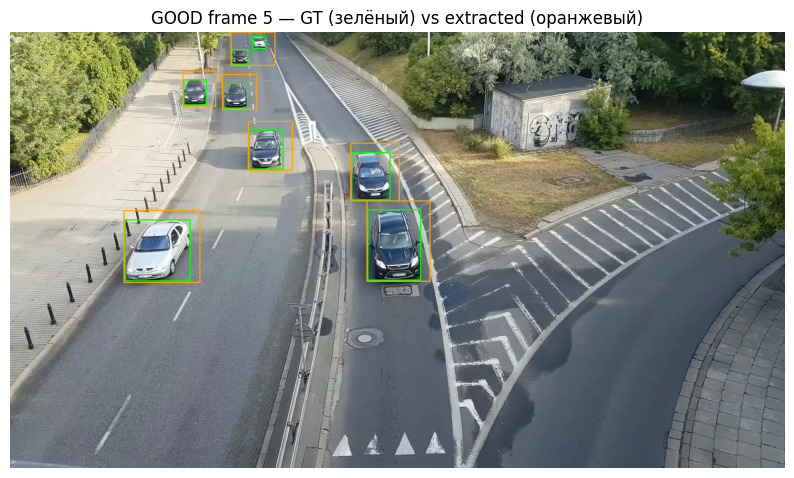

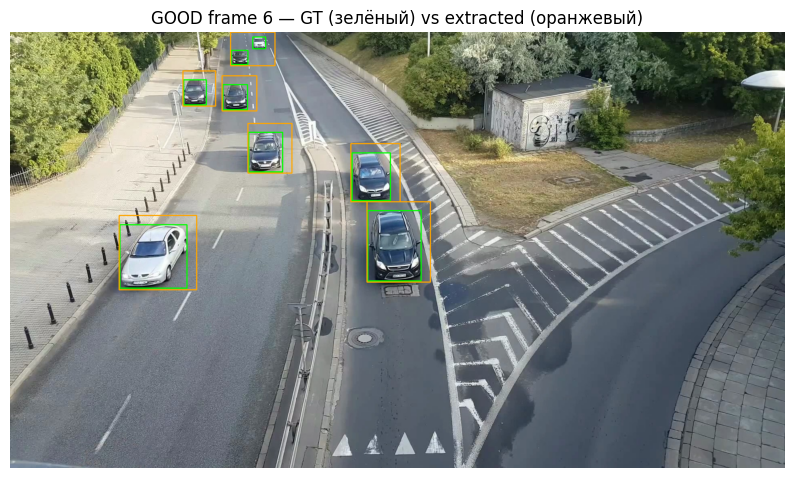

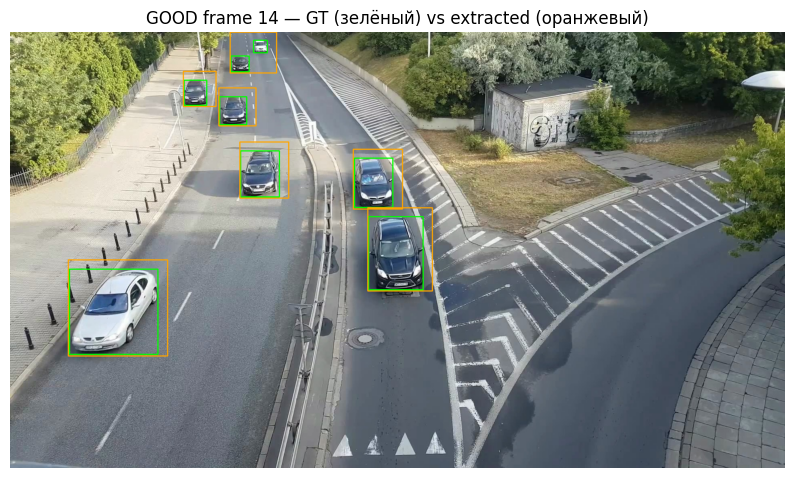

Неудачные извлечения:


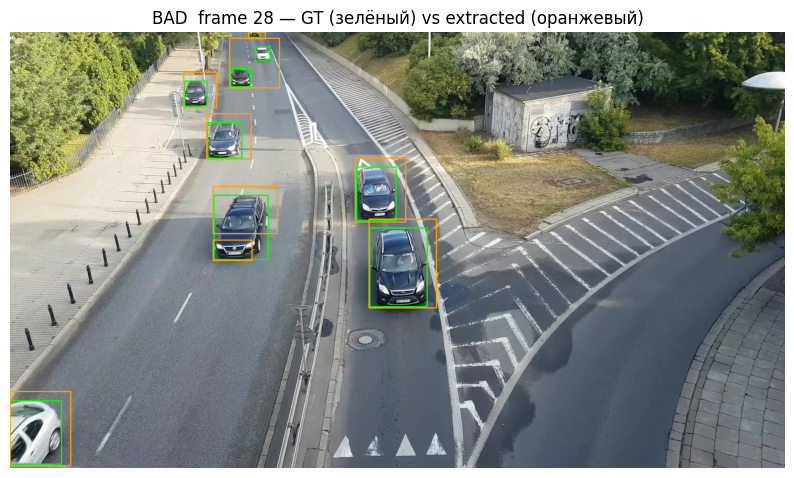

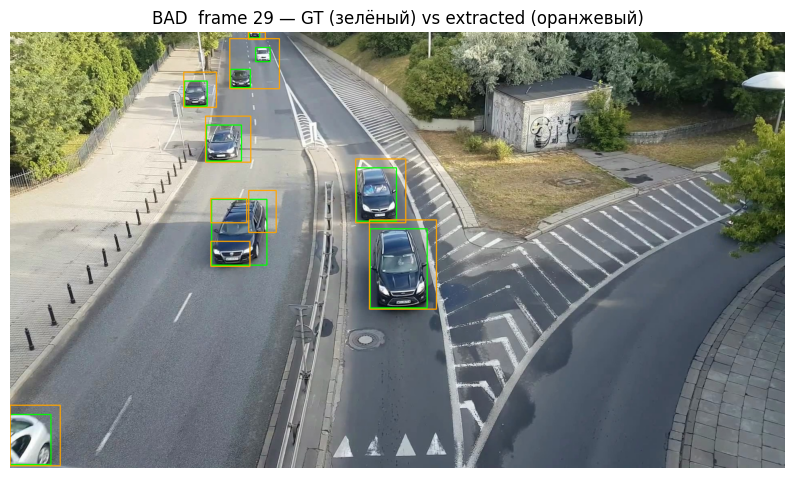

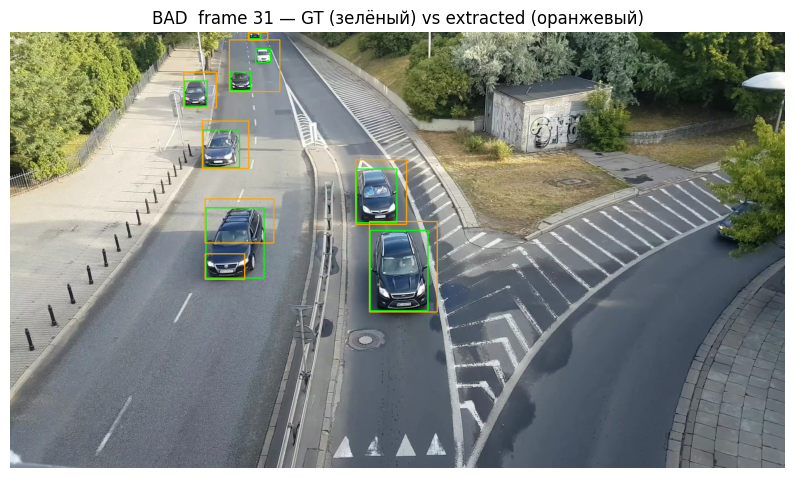

In [30]:
def show_frame_with_pred_and_gt(idx, extracted_for_idx, title_prefix=""):
    img = cv2.imread(str(FRAMES_INPUT_DIR / f"frame_{idx:05d}.jpg"))
    vis = img.copy()
    for _, x1, y1, x2, y2 in gt_by_frame.get(idx, []):
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    for x1, y1, x2, y2 in extracted_for_idx:
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 165, 255), 2)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"{title_prefix}frame {idx} — GT (зелёный) vs extracted (оранжевый)")
    plt.axis("off")
    plt.show()


print("Удачные извлечения:")
for f in good_frames:
    show_frame_with_pred_and_gt(f, best_extracted[f], "GOOD ")

print("Неудачные извлечения:")
for f in bad_frames:
    show_frame_with_pred_and_gt(f, best_extracted[f], "BAD  ")


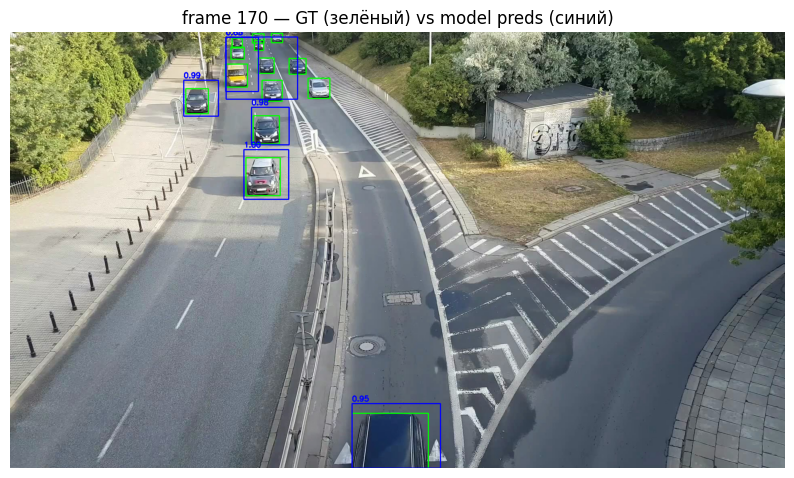

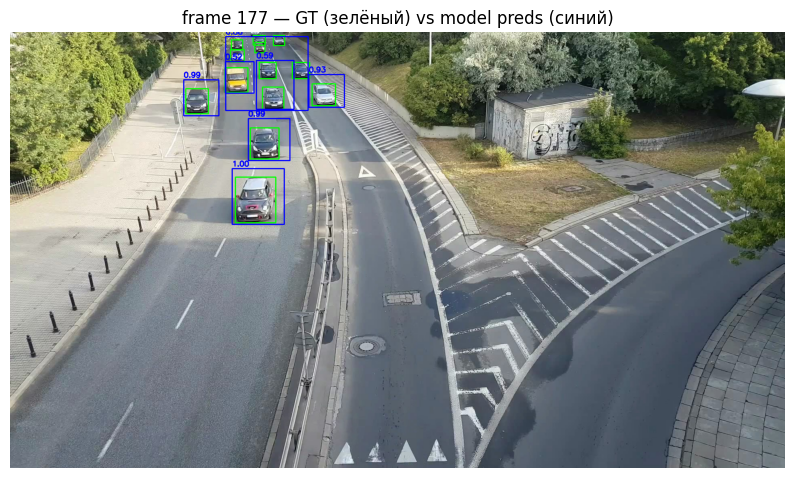

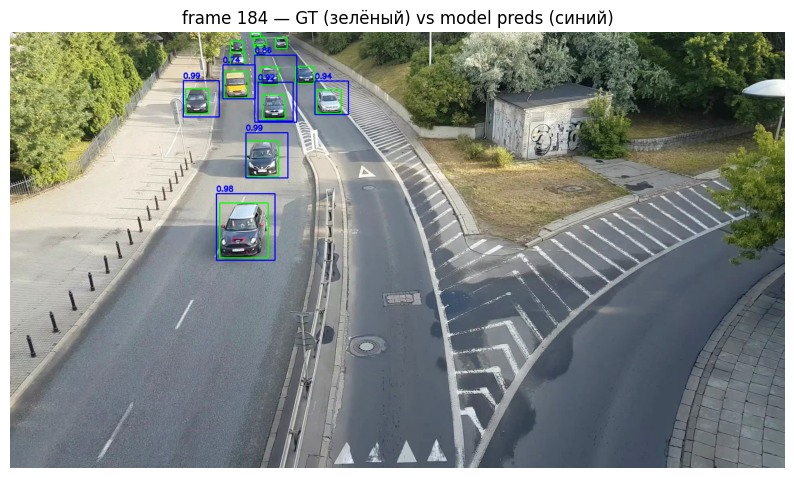

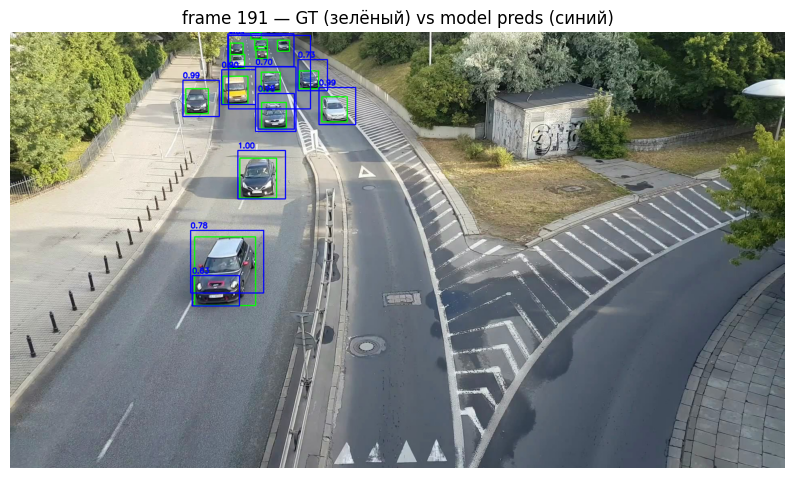

In [31]:
INFER_SIZE = TRAIN_RESIZE  # инференс делаю на том же разрешении, что и обучение


@torch.no_grad()
def model_predict(idx, score_thr=0.5):
    img_bgr = cv2.imread(str(FRAMES_INPUT_DIR / f"frame_{idx:05d}.jpg"))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img_rgb.shape[:2]
    new_w, new_h = INFER_SIZE
    img_small = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    img_t = torchvision.transforms.functional.to_tensor(img_small).to(DEVICE)
    model.eval()
    out = model([img_t])[0]
    boxes = out["boxes"].cpu().numpy()
    scores = out["scores"].cpu().numpy()
    keep = scores >= score_thr
    boxes = boxes[keep]
    scores = scores[keep]
    # масштабирую координаты обратно к исходному размеру кадра
    sx, sy = orig_w / new_w, orig_h / new_h
    if len(boxes):
        boxes = boxes * np.array([sx, sy, sx, sy], dtype=np.float32)
    return img_bgr, boxes, scores


def show_predictions(idx):
    img_bgr, boxes, scores = model_predict(idx)
    vis = img_bgr.copy()
    for _, x1, y1, x2, y2 in gt_by_frame.get(idx, []):
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    for (x1, y1, x2, y2), s in zip(boxes, scores):
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
        cv2.putText(vis, f"{s:.2f}", (int(x1), max(0, int(y1) - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"frame {idx} — GT (зелёный) vs model preds (синий)")
    plt.axis("off")
    plt.show()


sample_test = test_idx[:: max(1, len(test_idx) // 4)][:4]
for f in sample_test:
    show_predictions(f)


In [32]:
# Сборка видео с моей извлечённой разметкой.
def write_video(out_path, frame_indices, draw_fn, fps):
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, fps, (FRAME_W, FRAME_H))
    for fi in tqdm(frame_indices, desc=out_path.name):
        img = cv2.imread(str(FRAMES_INPUT_DIR / f"frame_{fi:05d}.jpg"))
        vis = draw_fn(img, fi)
        writer.write(vis)
    writer.release()


def draw_extracted(img, fi):
    out = img.copy()
    for x1, y1, x2, y2 in best_extracted.get(fi, []):
        cv2.rectangle(out, (int(x1), int(y1)), (int(x2), int(y2)), (0, 165, 255), 2)
    cv2.putText(out, f"extracted | frame {fi}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    return out


# Это занимает время — пишем все NUM_FRAMES кадров.
write_video(VIDEOS_DIR / "extracted_annotations.mp4", range(NUM_FRAMES), draw_extracted, FPS)
print("saved", VIDEOS_DIR / "extracted_annotations.mp4")


extracted_annotations.mp4:   0%|          | 0/301 [00:00<?, ?it/s]

saved /Users/delusionn/prog/data-analysis-frameworks-course/lab3/videos/extracted_annotations.mp4


In [33]:
# Видео с предсказаниями модели. Использую model_predict, чтобы Faster R-CNN
# работал на уменьшенном кадре, а bbox переводились обратно в координаты исходника.
def draw_model(img, fi):
    _, boxes, scores = model_predict(fi, score_thr=0.5)
    vis = img.copy()
    for (x1, y1, x2, y2), s in zip(boxes, scores):
        cv2.rectangle(vis, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
        cv2.putText(vis, f"{s:.2f}", (int(x1), max(0, int(y1) - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    cv2.putText(vis, f"model | frame {fi}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    return vis


model.eval()
write_video(VIDEOS_DIR / "model_predictions.mp4", range(NUM_FRAMES), draw_model, FPS)
print("saved", VIDEOS_DIR / "model_predictions.mp4")


model_predictions.mp4:   0%|          | 0/301 [00:00<?, ?it/s]

saved /Users/delusionn/prog/data-analysis-frameworks-course/lab3/videos/model_predictions.mp4


In [34]:
# Числовая сводка по работе — собираю конкретные значения для финального вывода.
best_row = metrics_df.loc[BEST_METHOD]
print(f"всего обработано кадров: {NUM_FRAMES}")
print(f"bbox в coco_full: {len(coco_full['annotations'])}")
print(f"размеры сплитов (train/val/test): {len(train_idx)}/{len(val_idx)}/{len(test_idx)}")
print()
print(f"лучший метод извлечения: {BEST_METHOD}")
print(f"  precision = {best_row['precision']:.4f}")
print(f"  recall    = {best_row['recall']:.4f}")
print(f"  F1        = {best_row['F1']:.4f}")
print(f"  mean IoU  = {best_row['mean_IoU']:.4f}")
print(f"  TP/FP/FN  = {int(best_row['TP'])}/{int(best_row['FP'])}/{int(best_row['FN'])}")
print()
print("метрики модели на test:")
for k in ("map", "map_50", "map_75", "mar_100"):
    if k in test_metrics:
        print(f"  {k:8s} = {test_metrics[k]:.4f}")
print()
print(f"лучший val mAP во время обучения: {best_map:.4f}")


всего обработано кадров: 301
bbox в coco_full: 2445
размеры сплитов (train/val/test): 140/30/30

лучший метод извлечения: diff
  precision = 0.4990
  recall    = 0.3345
  F1        = 0.4005
  mean IoU  = 0.6895
  TP/FP/FN  = 1220/1225/2427

метрики модели на test:
  map      = 0.7187
  map_50   = 0.9681
  map_75   = 0.8450
  mar_100  = 0.7651

лучший val mAP во время обучения: 0.6273


## 11. Финальный вывод

В этой лабораторной я:

1. Декодировал `input.mp4` и `output.mp4` на кадры (по одному JPEG на кадр в `frames/input/` и `frames/output/`).
2. Попробовал три способа извлечения bbox из видео с нарисованной разметкой:
   - **diff** — разница кадров + threshold + морфология;
   - **canny** — Canny по разности кадров;
   - **color** — HSV-маска по цвету рамок CVAT.
3. Сравнил их по mean IoU, precision, recall, F1, TP/FP/FN относительно эталона из `annotations.xml`. Конкретные числа — в таблице сравнения и в числовой сводке выше. Лучший по F1 метод взял как источник разметки.
4. Сформировал COCO-разметку (один класс `vehicle`) по всем кадрам видео и проверил её через `validate_coco`. Для обучения отобрал первые `TRAIN_FRAME_LIMIT` кадров и поделил 70/15/15 *по порядку*: соседние кадры почти одинаковые, случайный split дал бы оптимистическую оценку.
5. Дообучил `fasterrcnn_mobilenet_v3_large_fpn`, заменил голову под 2 класса, использовал early stopping по validation mAP, лучший чекпоинт сохранён в `models/best_model.pth`. Во время обучения логировал val_mAP, val_mAP@0.5, val_mAP@0.75, val_mAR@100.
6. Оценил модель на test через `torchmetrics`: посчитаны `mAP`, `mAP@0.5`, `mAP@0.75`, `mAR@100`. mAP@0.5 заметно выше, чем mAP — модель в целом находит машины, но не всегда попадает по контуру идеально.
7. Сделал визуализации: удачные кадры извлечения, провальные кадры, предсказания модели рядом с GT. Также собрал два видео: `videos/extracted_annotations.mp4` (input + моя разметка) и `videos/model_predictions.mp4` (input + предсказания модели).

**Главное ограничение работы — качество автоматически извлечённой разметки.** Лучший метод даёт неплохой IoU на совпавших bbox, но recall остаётся низким, поэтому часть объектов теряется. Из-за этого модель наследует ошибки extracted-разметки: если метод склеил два соседних bbox в один или пропустил машину — модель учится так же.

**Прочие ограничения:**

- bbox сложно вытащить, когда рамка сливается с фоном или с самим объектом;
- тонкие линии bbox иногда распадаются на куски и метод выдаёт несколько маленьких прямоугольников вместо одного;
- два соседних bbox склеиваются в один, потому что простое объединение по IoU их не различает;
- классы car/minivan не восстанавливаю — по нарисованным рамкам надёжно отличить их сложно, использую единый класс `vehicle`.

**Что можно улучшить:**

- подобрать threshold и параметры морфологии аккуратнее (например, через сетку по нескольким кадрам);
- добавить трекинг между кадрами (KCF/DeepSORT), чтобы сглаживать "рваную" разметку;
- руками поправить часть кадров и обучаться на смеси автоматической + ручной разметки;
- увеличить число эпох и добавить аугментации (flip, color jitter);
- попробовать RetinaNet или Faster R-CNN ResNet50 FPN — на тех же кадрах модель сильнее, но обучение дольше.
